Visualize what best fit parameters mean

In [1]:
import zeus21
from escripts import eMCMC
from escripts import edata
from escripts import eplots
import importlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

In [77]:
best_fit = [0.63, -0.06, -0.47, -0.04, 12.29, 0.24, -0.9, 0, 0.62, 0.02, -0.11]

# $M_{\rm{UV}}$ Gaussians

In [68]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [69]:
param_data = eMCMC.build_param_data({})

In [70]:
my_UVLF = eMCMC.UVLF(sorted_data, param_data)

In [71]:
def plot_MUV_dist(my_UVLF, zs, param_values, Mhtab):
    fig, ax = plt.subplots()
    MUV_range = np.linspace(-15, -24, 500)
    ax.invert_xaxis()
    
    cmap = LinearSegmentedColormap.from_list("custom", [eplots.red, eplots.navy])
    norm = BoundaryNorm(np.arange(min(Mhtab), max(Mhtab)+1, 1), cmap.N)
    
    my_UVLF.HMFintclass.Mhtab = 10**Mhtab 
    
    for z, ls in zip(zs, ['-', '--']):
    
        params = my_UVLF.time_evolution(param_values, z)
        astroparams = my_UVLF.param_wrapper(params)
        SFRlist = zeus21.sfrd.SFR_II(astroparams, my_UVLF.CosmoParams, my_UVLF.HMFintclass, 10**Mhtab, z, z)
        MUVbarlist = zeus21.UVLFs.MUV_of_SFR(SFRlist, astroparams._kappaUV)
        MUVbarlist = np.fmin(MUVbarlist, zeus21.constants._MAGMAX)

        ax.plot(MUV_range[0], 0, ls = ls, color = 'black', label = f'$z={z}$') # Make invisible line for the legend purposes


        for sigUV, MUV_bar, Mh in zip(params[-1], MUVbarlist, Mhtab):
            frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min())
            color = cmap(frac)
            ax.plot(MUV_range, gaussian(MUV_range, sigUV, MUV_bar), color = color, ls = ls)

    # Color bar things:
    boundaries = np.arange(Mhtab.min()-0.5, Mhtab.max()+1.5, 1) # set bin edges between mass values
    norm = BoundaryNorm(boundaries, cmap.N)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=Mhtab, aspect = 14)
    cbar.set_label(r'$\log_{10}{M_h}$')

    ax.set_ylabel(r'$p(M_{\rm{UV}}|M_h)$')
    ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
    ax.legend(loc = 'upper left')
    

    return fig

In [72]:
def gaussian(MUV_range, sigma_UV, MUV_bar):
    return (1/(sigma_UV * np.sqrt(2*np.pi)))*np.exp(-(MUV_range-MUV_bar)**2/(2*sigma_UV**2))

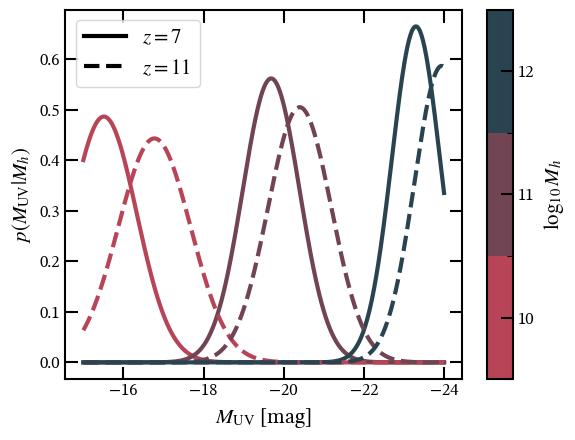

In [78]:
fig = plot_MUV_dist(my_UVLF, [7, 11], best_fit, Mhtab)

# SFE($M_h$) for different $z$

In [84]:
def plot_sfe_evolution(my_UVLF, param_values, zs, Mhtab):
    
    fig, ax = plt.subplots()
    cmap = LinearSegmentedColormap.from_list("custom", [eplots.red, eplots.navy])
    norm = BoundaryNorm(np.arange(min(Mhtab), max(Mhtab)+1, 1), cmap.N)

    for Mh in Mhtab:
        SFEs = np.zeros_like(zs)
        for i, z in enumerate(zs):
            params = my_UVLF.time_evolution(param_values, z)
            Astro_Parameters = my_UVLF.param_wrapper(params)
            SFEs[i] = zeus21.sfrd.fstarofz(Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mh)

        frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min())
        color = cmap(frac)
        print(SFEs)
        ax.plot(zs, SFEs, color = color, ls = '-')

    # Color bar things:
    boundaries = np.arange(Mhtab.min()-0.5, Mhtab.max()+1.5, 1) # set bin edges between mass values
    norm = BoundaryNorm(boundaries, cmap.N)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=Mhtab, aspect = 14)
    cbar.set_label(r'$\log_{10}{M_h}$')

    ax.set_ylabel('SFE')
    ax.set_xlabel('redshift')
    #ax.set_yscale('log')

    return fig

In [85]:
Mhtab = np.arange(10, 15, 1)

[0.00268231 0.00260786 0.00253697 0.00246947 0.00240519 0.002344
 0.00228575 0.0022303  0.00217754 0.00212734 0.0020796  0.00203419
 0.00199103 0.00195002 0.00191106 0.00187407 0.00183897 0.00180569
 0.00177415 0.00174429 0.00171604 0.00168934 0.00166414 0.00164039
 0.00161804 0.00159703 0.00157733 0.0015589  0.0015417  0.0015257
 0.00151086 0.00149716 0.00148456 0.00147305 0.00146259 0.00145318
 0.00144479 0.0014374  0.00143101 0.00142559 0.00142115 0.00141766
 0.00141513 0.00141355 0.00141292 0.00141324 0.0014145  0.00141671
 0.00141988 0.00142402 0.00142912 0.00143521 0.00144229 0.00145038
 0.0014595  0.00146967 0.0014809  0.00149322 0.00150666 0.00152125
 0.00153701 0.00155399 0.00157221 0.00159171 0.00161255 0.00163476
 0.00165839 0.0016835  0.00171015 0.00173839 0.00176829 0.00179991
 0.00183335 0.00186866 0.00190594 0.00194528 0.00198677 0.00203052
 0.00207663 0.00212522 0.00217643 0.00223037 0.00228719 0.00234705
 0.0024101  0.00247652 0.00254649 0.00262021 0.00269789 0.0027797

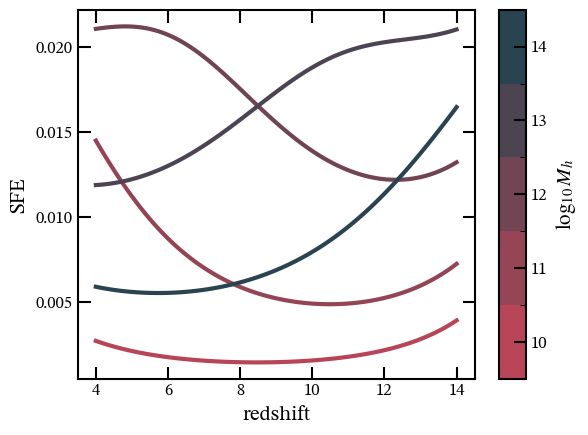

In [86]:
zs = np.linspace(4, 14, 100)
sfe_fig = plot_sfe_evolution(my_UVLF, best_fit, zs, Mhtab)